# 3. Python ML-моделирование

Быстрые ответы в самом низу

# ML-1. Базовая модель вероятности оплаты

## Задание

#### Контекст

Нужно построить первую baseline-модель, которая предсказывает вероятность оплаты в ближайшие 30 дней.

#### Дан файл

`train.csv`

Поля:

* `customer_id`
* `snapshot_date`
* `dpd_bucket`
* `outstanding_amount`
* `income`
* `region`
* `product_type`
* `contacts_last_7d`
* `rpc_last_30d`
* `promises_last_30d`
* `payments_amount_last_30d`
* `target_paid_30d`

#### Что нужно сделать

* Разделите данные по времени:
  * train: `2025-10-01` - `2025-12-31`
  * validation: `2026-01-01` - `2026-01-31`
* Постройте baseline-модель для `target_paid_30d`.
* Корректно обработайте пропуски и категориальные признаки.
* Посчитайте на validation:
  * `ROC-AUC`
  * `PR-AUC`
  * `precision@top30%`
* Коротко интерпретируйте результат.

#### Что прислать

Код, метрики и 3-4 предложения с выводами.

## Решение

### Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Предобработка и модель
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Метрики
from sklearn.metrics import roc_auc_score, average_precision_score

### Загрузка данных

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

In [ ]:
df.head()

,customer_id,snapshot_date,dpd_bucket,outstanding_amount,income,region,product_type,contacts_last_7d,rpc_last_30d,promises_last_30d,payments_amount_last_30d,target_paid_30d
0,100056,2025-10-01,1-30,10987.42,NaN,Siberia,micro_loan,3,0,1,0.00,0
1,100110,2025-10-01,61-90,30961.88,75940.84,Ural,installment,3,1,0,0.00,0
2,100111,2025-10-01,31-60,29000.38,82695.80,Center,installment,3,2,1,4746.34,1
3,100130,2025-10-01,1-30,21187.05,107453.10,Center,micro_loan,1,1,1,4280.34,1
4,100285,2025-10-01,1-30,33901.72,58239.00,South,micro_loan,1,0,0,2275.41,0


In [ ]:
df = df.drop(columns=["customer_id"])

- `customer_id` бесполезен для модели
- не несёт предиктивной информации
- технический идентификатор

### EDA

In [ ]:
print("Размер датасета:", df.shape)

Размер датасета: (6800, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   snapshot_date             6800 non-null   datetime64[ns]
 1   dpd_bucket                6800 non-null   object        
 2   outstanding_amount        6800 non-null   float64       
 3   income                    6234 non-null   float64       
 4   region                    6800 non-null   object        
 5   product_type              6800 non-null   object        
 6   contacts_last_7d          6800 non-null   int64         
 7   rpc_last_30d              6800 non-null   int64         
 8   promises_last_30d         6800 non-null   int64         
 9   payments_amount_last_30d  6800 non-null   float64       
 10  target_paid_30d           6800 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(4), object(3)
memory usage: 584.5+ KB


### Числовые признаки

In [ ]:
df.describe()

,snapshot_date,outstanding_amount,income,contacts_last_7d,rpc_last_30d,promises_last_30d,payments_amount_last_30d,target_paid_30d
count,6800,6800.000000,6234.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000
mean,2025-12-01 11:22:05.647058688,53500.138003,70233.192493,2.295735,1.372206,0.795000,6103.267091,0.386912
min,2025-10-01 00:00:00,3385.670000,14714.640000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2025-11-01 00:00:00,28533.730000,49268.835000,1.000000,0.000000,0.000000,1323.722500,0.000000
50%,2025-12-01 00:00:00,43556.995000,64644.895000,2.000000,1.000000,0.000000,3920.560000,0.000000
75%,2026-01-01 00:00:00,66615.017500,84593.090000,3.000000,2.000000,1.000000,8184.007500,1.000000
max,2026-01-31 00:00:00,419060.020000,326169.810000,8.000000,5.000000,4.000000,93942.110000,1.000000
std,NaN,37614.759931,29880.739430,1.668262,1.174003,1.062832,7532.299398,0.487079


In [ ]:
missing_table = df.isna().sum().to_frame("missing_count").reset_index(names="column")

missing_table["missing_share"] = missing_table["missing_count"] / len(df)
missing_table = missing_table[missing_table["missing_count"] > 0]
missing_table.sort_values("missing_count", ascending=False)

,column,missing_count,missing_share
3,income,566,0.083235


- признак `income` является числовым непрерывным признаком;
- отражает уровень дохода клиента;
- содержит ~8% пропущенных значений;
- перед обучением модели потребуется обработка пропусков.

In [ ]:
all_num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols = all_num_cols.drop(['contacts_last_7d','rpc_last_30d','promises_last_30d', 'target_paid_30d'])

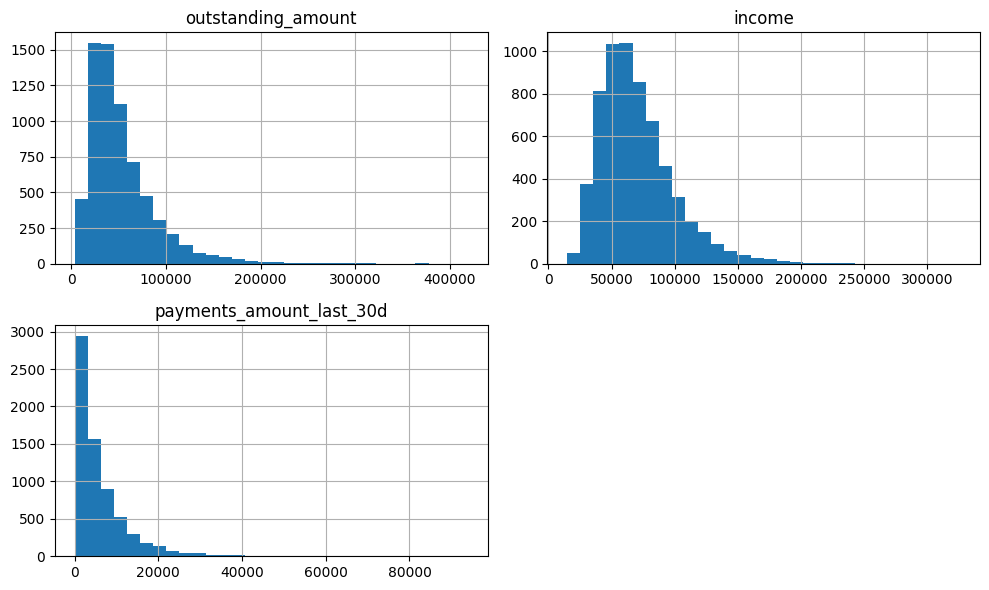

In [ ]:
df[num_cols].hist(figsize=(10, 6), bins=30)
plt.tight_layout()
plt.show()

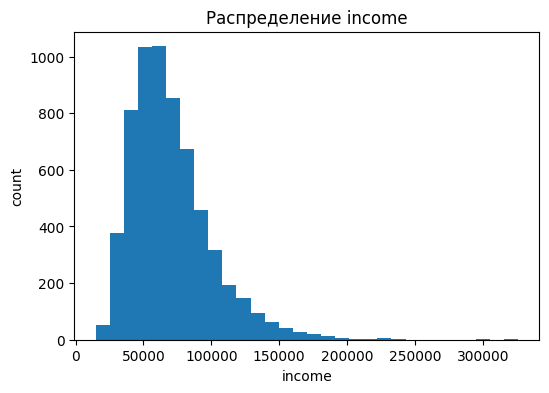

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["income"].dropna(), bins=30)
plt.title("Распределение income")
plt.xlabel("income")
plt.ylabel("count")
plt.show()

- Для финансовых признаков распределения скошены, что ожидаемо

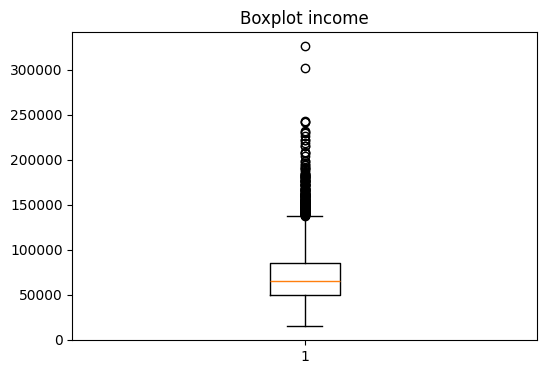

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(df["income"].dropna())
plt.title("Boxplot income")
plt.show()

- наблюдаются выбросы, что типично для финансовых данных

Для заполнения пропущенных значений(импутации) предлагаю median:
- устойчив к выбросам
- income почти всегда с перекосом (skewed)

### Категориальные признаки

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols

Index(['dpd_bucket', 'region', 'product_type'], dtype='object')

In [ ]:
num_cat_cols = pd.Index(['contacts_last_7d','rpc_last_30d','promises_last_30d'])
num_cat_cols

Index(['contacts_last_7d', 'rpc_last_30d', 'promises_last_30d'], dtype='object')

In [ ]:
bin_cat_cols = pd.Index(['target_paid_30d'])
bin_cat_cols

Index(['target_paid_30d'], dtype='object')

In [ ]:
all_cat_cols = cat_cols.append([num_cat_cols, bin_cat_cols])
all_cat_cols

Index(['dpd_bucket', 'region', 'product_type', 'contacts_last_7d',
       'rpc_last_30d', 'promises_last_30d', 'target_paid_30d'],
      dtype='object')

In [ ]:
df[all_cat_cols].nunique()

,0
dpd_bucket,4
region,6
product_type,4
contacts_last_7d,9
rpc_last_30d,6
promises_last_30d,5
target_paid_30d,2


In [ ]:
for col in all_cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))


dpd_bucket:
dpd_bucket
1-30     2706
31-60    1972
61-90    1332
90+       790
Name: count, dtype: int64

region:
region
Moscow     1711
Center     1405
South      1119
SPB         922
Ural        848
Siberia     795
Name: count, dtype: int64

product_type:
product_type
credit_card    2299
cash_loan      2138
installment    1560
micro_loan      803
Name: count, dtype: int64

contacts_last_7d:
contacts_last_7d
1    1628
2    1612
3    1264
0     854
4     736
5     390
6     192
7      71
8      53
Name: count, dtype: int64

rpc_last_30d:
rpc_last_30d
1    2372
0    1743
2    1564
3     744
4     286
5      91
Name: count, dtype: int64

promises_last_30d:
promises_last_30d
0    3635
1    1749
2     811
3     385
4     220
Name: count, dtype: int64

target_paid_30d:
target_paid_30d
0    4169
1    2631
Name: count, dtype: int64


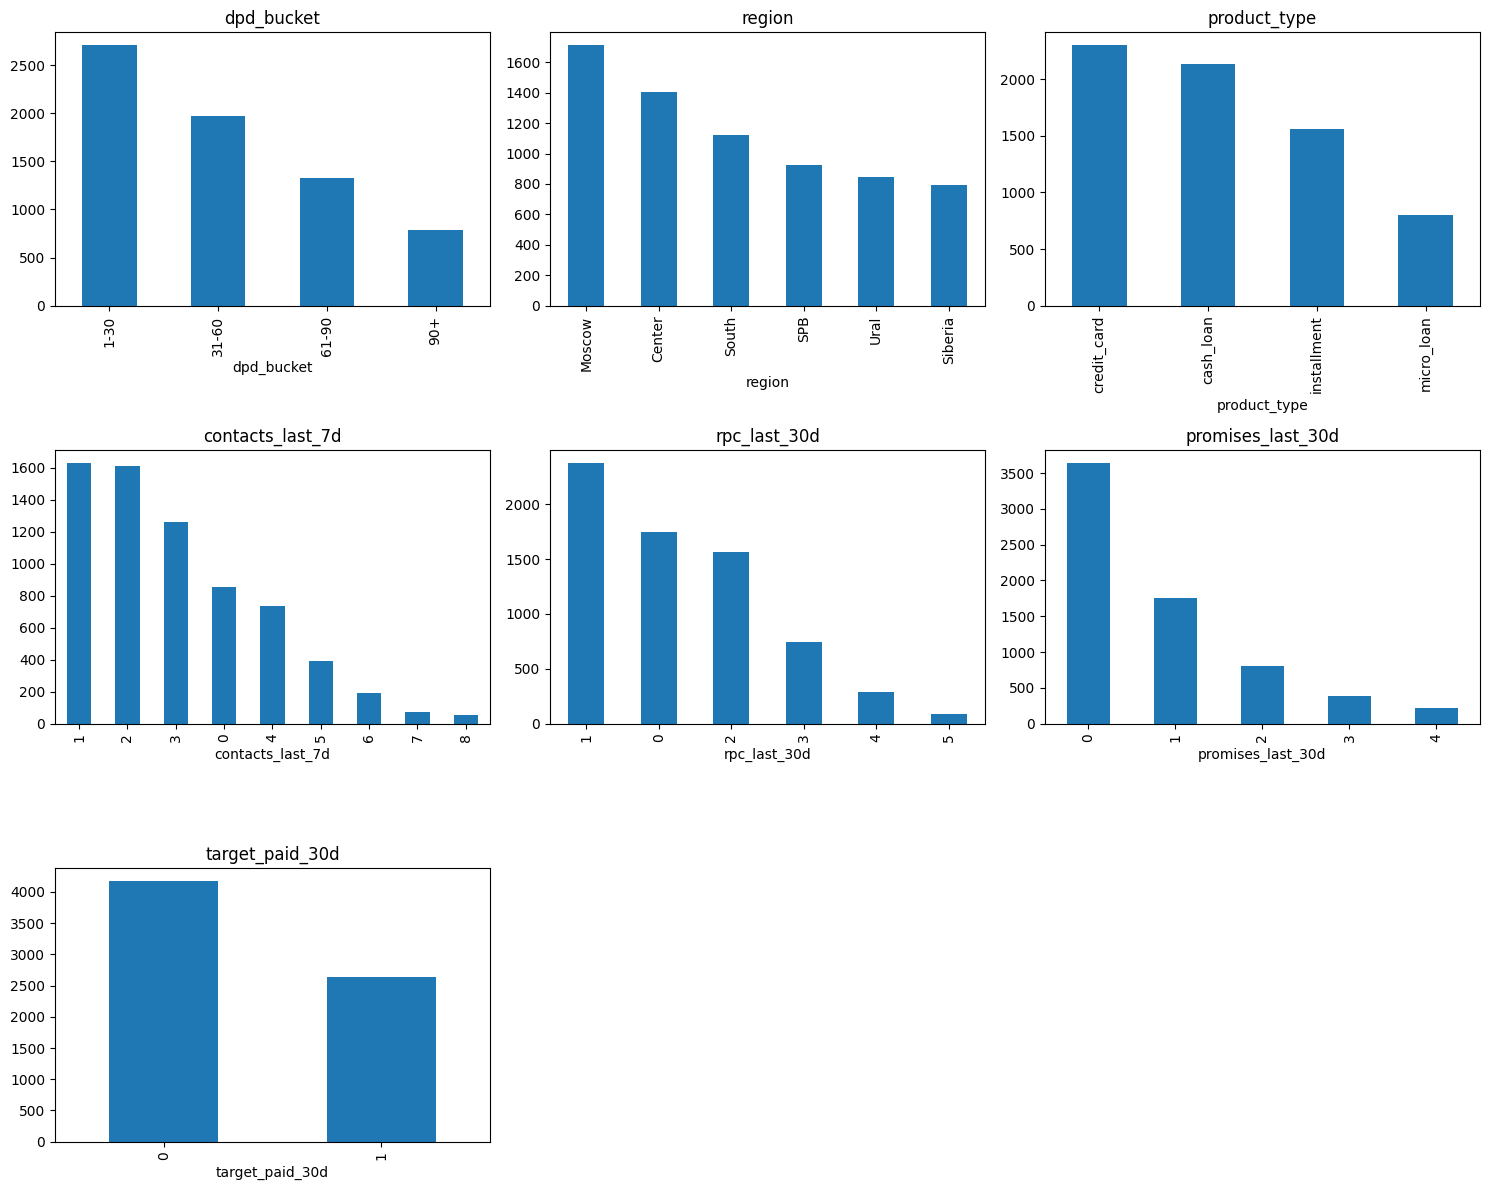

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 4 * 3))
axes = axes.flatten()

for i, col in enumerate(all_cat_cols):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

# удалить лишние пустые графики
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- таргет `target_paid_30d` имеет умеренный дисбаланс классов (~60/40), что не является критичным для baseline-модели;

- признаки `contacts_last_7d`, `rpc_last_30d`, `promises_last_30d` имеют распределение с выраженным правым хвостом(right skewed): большинство наблюдений сосредоточено в малых значениях, при этом встречаются редкие большие значения;

- объединение редких значений (например, "5+") теоретически возможно, однако для baseline-модели не требуется, так как:
  - данные имеют ограниченный размер;
  - каждая категория может содержать полезную информацию;
  - модель способна корректно работать с такими распределениями;

- признак `dpd_bucket` имеет упорядоченную структуру, однако в рамках baseline-модели будет обработан как категориальный признак.

---

Итог по блоку:
- числовые признаки (`income`, `outstanding_amount`, `payments_amount_last_30d`) обрабатываются как непрерывные;

- дискретные признаки с количеством событий (`contacts_last_7d`, `rpc_last_30d`, `promises_last_30d`) оставлены числовыми, так как сохраняют порядок значений и не требуют дополнительного кодирования;

- категориальные признаки (`region`, `product_type`, `dpd_bucket`) обрабатываются отдельно с использованием OneHotEncoder;

- такой подход позволяет сохранить простоту baseline-модели, не увеличивая избыточно размерность и избегая переусложнения решения.

### Проверка дат и таргета

In [ ]:
# Диапазон дат
print("Минимальная дата:", df["snapshot_date"].min())
print("Максимальная дата:", df["snapshot_date"].max())

Минимальная дата: 2025-10-01 00:00:00
Максимальная дата: 2026-01-31 00:00:00


In [ ]:
target_distribution = (df["target_paid_30d"].value_counts().reset_index())

target_distribution.columns = ["target", "count"]
target_distribution["share"] = target_distribution["count"] / len(df)

target_distribution

,target,count,share
0,0,4169,0.613088
1,1,2631,0.386912


- таргет `target_paid_30d` имеет умеренный дисбаланс классов.

### train / validation по времени (Time-based split)

In [ ]:
# Периоды
train_start = "2025-10-01"
train_end = "2025-12-31"

val_start = "2026-01-01"
val_end = "2026-01-31"

In [ ]:
# Разделение по времени
train_df = df[(df["snapshot_date"] >= train_start) & (df["snapshot_date"] <= train_end)].copy()
val_df = df[(df["snapshot_date"] >= val_start) & (df["snapshot_date"] <= val_end)].copy()

In [ ]:
print("Размер train:", train_df.shape)
print("Размер validation:", val_df.shape)

Размер train: (5059, 11)
Размер validation: (1741, 11)


In [ ]:
# Проверка диапазонов дат
print("Train period:")
print("  min date:", train_df["snapshot_date"].min())
print("  max date:", train_df["snapshot_date"].max())

print("\nValidation period:")
print("  min date:", val_df["snapshot_date"].min())
print("  max date:", val_df["snapshot_date"].max())

Train period:
  min date: 2025-10-01 00:00:00
  max date: 2025-12-31 00:00:00

Validation period:
  min date: 2026-01-01 00:00:00
  max date: 2026-01-31 00:00:00


In [ ]:
# Распределение таргета в train
train_target_dist = train_df["target_paid_30d"].value_counts().reset_index()
train_target_dist.columns = ["target", "count"]
train_target_dist["share"] = train_target_dist["count"] / len(train_df)

train_target_dist

,target,count,share
0,0,3105,0.613758
1,1,1954,0.386242


In [ ]:
# Распределение таргета в validation
val_target_dist = val_df["target_paid_30d"].value_counts().reset_index()
val_target_dist.columns = ["target", "count"]
val_target_dist["share"] = val_target_dist["count"] / len(val_df)

val_target_dist

,target,count,share
0,0,1064,0.611143
1,1,677,0.388857


- Сбалансированы примерно одинаково

### Подготовка признаков и таргета

In [ ]:
# Таргет
y_train = train_df["target_paid_30d"]
y_val = val_df["target_paid_30d"]

In [ ]:
# Признаки
X_train = train_df.drop(columns=["target_paid_30d", "snapshot_date"]) # в этом случае, дата тоже не участвует в обучении
X_val = val_df.drop(columns=["target_paid_30d", "snapshot_date"])

Разделяем признаки

In [ ]:
num_cols = ["income", "outstanding_amount", "contacts_last_7d", "rpc_last_30d",
            "promises_last_30d", "payments_amount_last_30d"]

cat_cols = ["region", "product_type", "dpd_bucket"]

### Предобработка данных (Preproccesing)

In [ ]:
# Заполнение числовых признаков (по факту только income)
num_medians = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(num_medians)
X_val[num_cols] = X_val[num_cols].fillna(num_medians)

In [ ]:
# Заполнение категориальных (пропусков не было, но пусть будет)
X_train[cat_cols] = X_train[cat_cols].fillna("missing")
X_val[cat_cols] = X_val[cat_cols].fillna("missing")

### Нормализация (StandardScaler)

Числовые признаки имеют различный масштаб, из-за чего признаки с большими значениями могут доминировать при обучении логистической регрессии.  
Для устранения этого эффекта выполнено масштабирование с помощью StandardScaler.

In [ ]:
# Масштабирование числовых признаков
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

### Кодирование категориальных признаков

In [ ]:
encoder = OneHotEncoder(handle_unknown="ignore")
encoder.fit(X_train[cat_cols])

OneHotEncoder(handle_unknown='ignore')

In [ ]:
# Кодируем
X_train_cat = encoder.transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])

cat_feature_names = encoder.get_feature_names_out(cat_cols)

# Превращаем в DataFrame
X_train_cat = pd.DataFrame(X_train_cat.toarray(), columns=cat_feature_names, index=X_train.index)
X_val_cat = pd.DataFrame(X_val_cat.toarray(), columns=cat_feature_names,index=X_val.index)

# Убираем категориальные до кодирования
X_train_num = X_train[num_cols]
X_val_num = X_val[num_cols]

# Собираем
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_val = pd.concat([X_val_num, X_val_cat], axis=1)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (5059, 20)
Validation shape: (1741, 20)


### Обучение baseline-модели (LogReg)

В качестве baseline выбрана логистическая регрессия  
Это стандартная модель для бинарной классификации:  
она проста, интерпретируема, быстро обучается и позволяет получить вероятности оплаты, необходимые для расчёта ROC-AUC, PR-AUC и precision@top30%.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Обучаем baseline-модель
model = LogisticRegression(random_state=81, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=81)

In [ ]:
# Вероятности положительного класса на validation
val_proba = model.predict_proba(X_val)[:, 1]
val_proba[:10]

array([0.11210478, 0.18702686, 0.35879033, 0.67177941, 0.92931769,
       0.30719098, 0.34241576, 0.88672876, 0.25291549, 0.27744683])

### Метрики (ROC-AUC, PR-AUC, Precision@top30%)

In [ ]:
roc_auc = roc_auc_score(y_val, val_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.789407047900401


`ROC-AUC` показывает способность модели корректно ранжировать клиентов по вероятности оплаты

In [ ]:
pr_auc = average_precision_score(y_val, val_proba)
print("PR-AUC:", pr_auc)

PR-AUC: 0.7190740807517535


`PR-AUC` отражает качество модели с учётом дисбаланса классов

In [ ]:
val_df_eval = pd.DataFrame({"y_true": y_val,
                            "y_proba": val_proba})

# Сортируем по вероятности
val_df_eval = val_df_eval.sort_values("y_proba", ascending=False)

# Топ 30%
top_30_percent = int(len(val_df_eval) * 0.3)
val_top = val_df_eval.head(top_30_percent)

precision_top30 = val_top["y_true"].mean()

print("Precision@top30%:", precision_top30)

Precision@top30%: 0.7030651340996169


`precision@top30%` показывает долю платящих клиентов среди 30% с наибольшей предсказанной вероятностью

In [ ]:
metrics_table = pd.DataFrame({"metric": ["ROC-AUC", "PR-AUC", "precision@top30%"],
                              "value": [roc_auc, pr_auc, precision_top30]})
metrics_table

,metric,value
0,ROC-AUC,0.789407
1,PR-AUC,0.719074
2,precision@top30%,0.703065


### Интерпретация

- Модель показывает хорошее качество ранжирования (`ROC-AUC ~0.79`), что говорит о способности корректно упорядочивать клиентов по вероятности оплаты.
- `PR-AUC ~0.72` подтверждает стабильность модели с учётом умеренного дисбаланса классов.
- Метрика `precision@top30% ~0.70` практически важна: модель позволяет выделить сегмент клиентов, в котором доля реально платящих значительно выше среднего, что делает её пригодной для задач приоритизации коммуникаций.  
Модель эффективно выделяет наиболее перспективных клиентов.

## Pipeline-версия решения

### Preprocessor

In [ ]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat", cat_transformer, cat_cols)])

### Full Pipeline

In [ ]:
pipeline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42, max_iter=5000))])

### Обучение

In [ ]:
X_train_raw = train_df.drop(columns=["target_paid_30d", "snapshot_date"])
X_val_raw = val_df.drop(columns=["target_paid_30d", "snapshot_date"])

y_train = train_df["target_paid_30d"]
y_val = val_df["target_paid_30d"]

In [ ]:
pipeline_model.fit(X_train_raw, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['income',
                                                   'outstanding_amount',
                                                   'contacts_last_7d',
                                                   'rpc_last_30d',
                                                   'promises_last_30d',
                                                   'payments_amount_last_30d']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['region', 'product_type',
                                                   'dpd_bucket'])])),
                ('model', LogisticRegression(max_iter=5000, random_state=42))])

In [ ]:
val_proba_pipe = pipeline_model.predict_proba(X_val_raw)[:, 1]

### Метрики

In [ ]:
roc_auc_pipe = roc_auc_score(y_val, val_proba_pipe)
pr_auc_pipe = average_precision_score(y_val, val_proba_pipe)

val_eval_pipe = pd.DataFrame({"y_true": y_val,
                              "y_proba": val_proba_pipe}).sort_values("y_proba", ascending=False)
top_n = int(len(val_eval_pipe) * 0.3)
precision_top30_pipe = val_eval_pipe.head(top_n)["y_true"].mean()

In [ ]:
pipeline_metrics = pd.DataFrame({"metric": ["ROC-AUC", "PR-AUC", "precision@top30%"],
                                 "value": [roc_auc_pipe, pr_auc_pipe, precision_top30_pipe]})

In [ ]:
pipeline_metrics

,metric,value
0,ROC-AUC,0.789407
1,PR-AUC,0.719074
2,precision@top30%,0.703065


- Метрики идентичны

# ML-2. Бустинг и сравнение с baseline

## Задание

#### Контекст

После baseline нужно проверить, дает ли бустинг заметное улучшение качества.

#### Даны данные

Используйте тот же `train.csv`, что и в задаче `ML-1`.

#### Что нужно сделать

* Обучите одну из моделей бустинга: `CatBoost`, `LightGBM` или `XGBoost`.
* Используйте time-based validation.
* Сравните качество бустинга с baseline из задачи `ML-1`.
* Покажите топ-10 наиболее важных признаков.
* Посчитайте метрики не только в целом, но и отдельно по:
  * `dpd_bucket`
  * `region`

#### Что нужно получить

Короткий отчет, из которого понятно:

* стало ли качество лучше;
* нет ли деградации на отдельных сегментах;
* какие признаки сильнее всего влияют на предсказание.

## Решение

### Импорт библиотек

In [ ]:
!pip install catboost -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score, average_precision_score

### Загрузка данных

In [ ]:
df = pd.read_csv("train.csv")

In [ ]:
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
df = df.drop(columns=["customer_id"])

In [ ]:
df.head()

,snapshot_date,dpd_bucket,outstanding_amount,income,region,product_type,contacts_last_7d,rpc_last_30d,promises_last_30d,payments_amount_last_30d,target_paid_30d
0,2025-10-01,1-30,10987.42,NaN,Siberia,micro_loan,3,0,1,0.00,0
1,2025-10-01,61-90,30961.88,75940.84,Ural,installment,3,1,0,0.00,0
2,2025-10-01,31-60,29000.38,82695.80,Center,installment,3,2,1,4746.34,1
3,2025-10-01,1-30,21187.05,107453.10,Center,micro_loan,1,1,1,4280.34,1
4,2025-10-01,1-30,33901.72,58239.00,South,micro_loan,1,0,0,2275.41,0


### Time-based Split

In [ ]:
train_df = df[(df["snapshot_date"] >= "2025-10-01") & (df["snapshot_date"] <= "2025-12-31")].copy()
val_df = df[(df["snapshot_date"] >= "2026-01-01") & (df["snapshot_date"] <= "2026-01-31")].copy()

In [ ]:
print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (5059, 11)
Validation shape: (1741, 11)


### X(признаки) / y (таргет)

In [ ]:
y_train = train_df["target_paid_30d"]
y_val = val_df["target_paid_30d"]

X_train = train_df.drop(columns=["target_paid_30d", "snapshot_date"])
X_val = val_df.drop(columns=["target_paid_30d", "snapshot_date"])

### Категориальные признаки

In [ ]:
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

In [ ]:
cat_cols

['dpd_bucket', 'region', 'product_type']

### Preprocessing

In [ ]:
# Числовые
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_medians = X_train[num_cols].median()

X_train[num_cols] = X_train[num_cols].fillna(num_medians)
X_val[num_cols] = X_val[num_cols].fillna(num_medians)

In [ ]:
# Категориальные
X_train[cat_cols] = X_train[cat_cols].fillna("missing")
X_val[cat_cols] = X_val[cat_cols].fillna("missing")

### Обучение CatBoost

In [ ]:
model_cb = CatBoostClassifier(iterations=2000,
                              learning_rate=0.03,
                              depth=5,
                              l2_leaf_reg=2,
                              random_state=81,
                              verbose=0)

model_cb.fit(X_train, y_train,
             cat_features=cat_cols,
             eval_set=(X_val, y_val),
             early_stopping_rounds=50,
             verbose=0)

CatBoostClassifier(depth=5, iterations=2000, l2_leaf_reg=2, learning_rate=0.03, random_state=81, verbose=0)

### Предсказания

In [ ]:
val_proba_cb = model_cb.predict_proba(X_val)[:, 1]

### Метрики

In [ ]:
roc_auc_cb = roc_auc_score(y_val, val_proba_cb)

In [ ]:
pr_auc_cb = average_precision_score(y_val, val_proba_cb)

In [ ]:
val_eval_cb = pd.DataFrame({"y_true": y_val,
                            "y_proba": val_proba_cb}).sort_values("y_proba", ascending=False)

top_n = int(len(val_eval_cb) * 0.3)
precision_top30_cb = val_eval_cb.head(top_n)["y_true"].mean()

In [ ]:
metrics_cb = pd.DataFrame({
    "metric": ["ROC-AUC", "PR-AUC", "precision@top30%"],
    "value": [roc_auc_cb, pr_auc_cb, precision_top30_cb]
})

In [ ]:
metrics_cb

,metric,value
0,ROC-AUC,0.788510
1,PR-AUC,0.715904
2,precision@top30%,0.708812


### Сравнение с baseline

In [ ]:
comparison = pd.DataFrame({
    "metric": ["ROC-AUC", "PR-AUC", "precision@top30%"],
    "baseline": [roc_auc, pr_auc, precision_top30],
    "catboost": [roc_auc_cb, pr_auc_cb, precision_top30_cb]
})

In [ ]:
comparison

,metric,baseline,catboost
0,ROC-AUC,0.789407,0.788510
1,PR-AUC,0.719074,0.715904
2,precision@top30%,0.703065,0.708812


Для модели "из коробки":

|metric	|baseline	|catboost |
|-------|---------|---------|
|ROC-AUC|	0.789407|	0.788510|
|PR-AUC |	0.719074|	0.715904|
|precision@top30% |	0.703065|	0.708812|

### Интерпретация

После подбора гиперпараметров (в частности, использования `l2_leaf_reg=2` и `early_stopping_rounds=50`) модель CatBoost достигла качества, сопоставимого с baseline.

- `ROC-AUC` и `PR-AUC` остались на близком уровне;
- при этом наблюдается **небольшое** улучшение по метрике `precision@top30%`.

Это означает, что модель CatBoost лучше выделяет наиболее перспективных клиентов, несмотря на отсутствие заметного улучшения глобальных метрик.

**Вывод**

CatBoost не даёт значительного выигрыша по классическим метрикам качества, однако показывает более высокую эффективность в задаче ранжирования клиентов, что важно с практической точки зрения.

**Возможные направления улучшения**

- более глубокий подбор гиперпараметров;
- анализ кривых обучения (train/validation) для оценки переобучения;
- расширение признакового пространства (feature engineering);
- тестирование других моделей бустинга или ансамблей.

### Важность признаков (Feature Importance)

In [ ]:
feature_importance = model_cb.get_feature_importance()

feature_names = X_train.columns

fi_df = pd.DataFrame({"feature": feature_names,
                      "importance": feature_importance}).sort_values("importance", ascending=False)

In [ ]:
fi_df.head(10)

,feature,importance
0,dpd_bucket,19.869247
7,promises_last_30d,16.857455
1,outstanding_amount,14.745563
6,rpc_last_30d,12.698239
5,contacts_last_7d,9.448322
4,product_type,8.871811
8,payments_amount_last_30d,6.277889
3,region,5.698600
2,income,5.532875


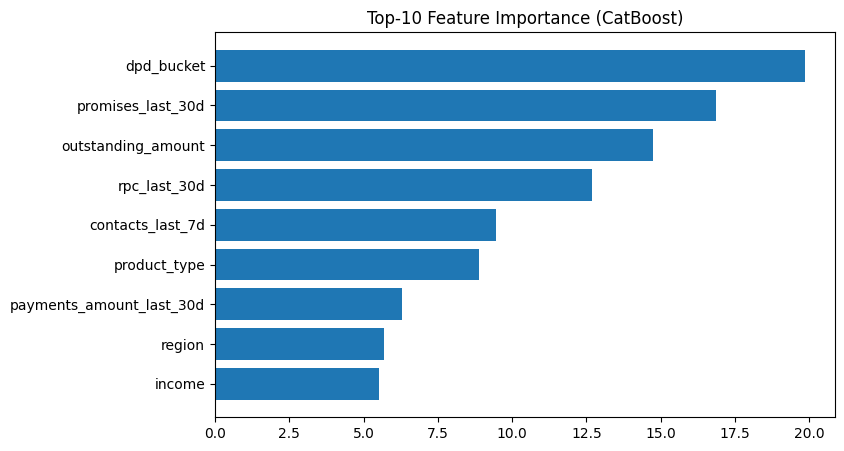

In [ ]:
top10 = fi_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10["feature"], top10["importance"])
plt.gca().invert_yaxis()
plt.title("Top-10 Feature Importance (CatBoost)")
plt.show()

1. Наиболее значимым признаком является `dpd_bucket`, отражающий уровень просрочки. Это ожидаемо, так как текущий статус задолженности напрямую связан с вероятностью оплаты.

2. Среди наиболее важных также находятся поведенческие признаки:
    - `promises_last_30d`
    - `rpc_last_30d`
    - `contacts_last_7d`  
    Они отражают недавнюю активность клиента и взаимодействие с ним, что является сильным индикатором будущего поведения.

3. Финансовые характеристики (`outstanding_amount`, `payments_amount_last_30d`, `income`) также оказывают влияние, но уступают по важности поведенческим факторам.

4. Категориальные признаки (`product_type`, `region`) имеют меньший вклад, что говорит о том, что индивидуальное поведение клиента важнее его принадлежности к сегменту.

Модель в первую очередь опирается на поведенческие и статусные признаки, а не на статические характеристики клиента.

### Сегментный анализ

In [ ]:
val_proba_baseline = pipeline_model.predict_proba(X_val_raw)[:, 1]

In [ ]:
val_eval = pd.DataFrame({
    "y_true": y_val,
    "baseline_proba": val_proba_baseline,
    "catboost_proba": val_proba_cb,
    "dpd_bucket": val_df["dpd_bucket"].values,
    "region": val_df["region"].values})

In [ ]:
def compute_metrics_compare(df):
    def metrics(y_true, y_proba):
        roc = roc_auc_score(y_true, y_proba)
        pr = average_precision_score(y_true, y_proba)

        top_n = int(len(df) * 0.3)
        precision_top = (
            df.assign(tmp_proba=y_proba)
              .sort_values("tmp_proba", ascending=False)
              .head(top_n)["y_true"]
              .mean()
        )

        return roc, pr, precision_top

    roc_b, pr_b, p30_b = metrics(df["y_true"], df["baseline_proba"])
    roc_c, pr_c, p30_c = metrics(df["y_true"], df["catboost_proba"])

    return pd.Series({"roc_auc_baseline": roc_b,
                      "roc_auc_catboost": roc_c,
                      "pr_auc_baseline": pr_b,
                      "pr_auc_catboost": pr_c,
                      "p30_baseline": p30_b,
                      "p30_catboost": p30_c})

In [ ]:
dpd_metrics = (val_eval
    .groupby("dpd_bucket")
    .apply(compute_metrics_compare)
    .reset_index())

/tmp/ipykernel_25235/1372156511.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_metrics_compare)


In [ ]:
dpd_metrics

,dpd_bucket,roc_auc_baseline,roc_auc_catboost,pr_auc_baseline,pr_auc_catboost,p30_baseline,p30_catboost
0,1-30,0.761277,0.759299,0.779511,0.774594,0.787440,0.772947
1,31-60,0.772585,0.773488,0.671260,0.672765,0.680851,0.666667
2,61-90,0.793526,0.793002,0.655967,0.656898,0.630631,0.612613
3,90+,0.785890,0.773858,0.553583,0.518803,0.491803,0.459016


In [ ]:
region_metrics = (val_eval
    .groupby("region")
    .apply(compute_metrics_compare)
    .reset_index())

/tmp/ipykernel_25235/2916586707.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_metrics_compare)


In [ ]:
region_metrics

,region,roc_auc_baseline,roc_auc_catboost,pr_auc_baseline,pr_auc_catboost,p30_baseline,p30_catboost
0,Center,0.759719,0.759788,0.709283,0.706156,0.701923,0.682692
1,Moscow,0.764754,0.765858,0.698578,0.697435,0.717742,0.717742
2,SPB,0.792714,0.790366,0.725458,0.716132,0.688312,0.662338
3,Siberia,0.787692,0.784957,0.727833,0.724804,0.719298,0.684211
4,South,0.821627,0.819333,0.741825,0.735153,0.722222,0.722222
5,Ural,0.841971,0.830253,0.792723,0.781699,0.705882,0.720588


#### По dpd_bucket

В сегменте с умеренной просрочкой (`31-60`) CatBoost показывает улучшение по метрике precision@top30%, что указывает на лучшую способность выделять наиболее перспективных клиентов в этом диапазоне.

Однако в других сегментах, особенно в группе с высокой просрочкой (`90+`), наблюдается снижение качества по всем метрикам. Это может свидетельствовать о том, что модель хуже обобщает поведение клиентов в крайних сегментах.

#### По region

По региональному разрезу модели демонстрируют сопоставимое качество. Существенного выигрыша CatBoost не наблюдается, при этом в ряде регионов baseline-модель показывает более стабильные результаты.

#### Итог

CatBoost не даёт устойчивого улучшения качества по сегментам и в некоторых случаях демонстрирует деградацию, особенно в сложных группах клиентов.

Таким образом, несмотря на небольшое улучшение по метрике precision@top30% в целом, baseline-модель остаётся более стабильной и предсказуемой в различных сегментах.

### XGBoost результаты (из интереса)

|metric	|baseline	|catboost	|xgboost|
|-------|---------|---------|-------|
|ROC-AUC|	0.789407|	0.788510|	0.773753|
|PR-AUC |	0.719074|	0.715904|	0.696273|
|precision@top30%|	0.703065|	0.708812|	0.685824|

## ОТЧЁТ

В рамках задачи была проведена оценка baseline-модели (логистическая регрессия) и моделей бустинга (CatBoost и XGBoost).

#### Качество моделей

- CatBoost показал сопоставимое качество с baseline по ROC-AUC и PR-AUC, а также небольшое улучшение по метрике precision@top30%;
- XGBoost не продемонстрировал значимого улучшения по сравнению с baseline;
- в целом бустинг не дал существенного прироста качества по классическим метрикам.

Таким образом, качество моделей бустинга оказалось близким к baseline, без явного выигрыша.

---

#### Анализ по сегментам

- В большинстве сегментов (`region`) модели демонстрируют сопоставимое качество;
- В разрезе `dpd_bucket` наблюдается:
  - локальное улучшение CatBoost в сегменте `31-60`;
  - деградация качества в сегменте с высокой просрочкой (`90+`);
- Существенных и устойчивых улучшений по всем сегментам не наблюдается.

Таким образом, CatBoost не показывает стабильного преимущества и в отдельных сегментах может уступать baseline.

---

#### Важность признаков

Наиболее значимыми признаками являются:

- `dpd_bucket` — отражает уровень просрочки;
- поведенческие признаки: `promises_last_30d`, `rpc_last_30d`, `contacts_last_7d`;
- финансовые признаки: `outstanding_amount`, `payments_amount_last_30d`.

Это соответствует бизнес-логике: поведение клиента и его текущий статус задолженности являются ключевыми факторами при прогнозировании оплаты.

### Общий вывод

Модели бустинга не дают устойчивого улучшения качества по сравнению с baseline.  
Логистическая регрессия остаётся конкурентоспособным и более стабильным решением для данной задачи.

# ML-3. Порог отсечения, бизнес-эффект и мониторинг

## Задача

#### Контекст

Модель планируется использовать для приоритизации клиентов на обзвон. Контактный центр ограничен по ресурсу, поэтому важно выбрать порог и оценить эффект для бизнеса.

#### Даны файлы

`scoring_results.csv`

* `customer_id`
* `snapshot_date`
* `score` - предсказанная моделью вероятность оплаты
* `target_paid_30d`
* `recovered_amount_30d`
* `dpd_bucket`
* `region`
* `current_contact_flg` - клиент входил в текущую стратегию обзвона (`0/1`)

`train_scores.csv`

* `customer_id`
* `snapshot_date`
* `score`

#### Бизнес-правила

* В день можно обзвонить только `25%` клиентов с наибольшим score.
* Стоимость одного контакта: `35` рублей.
* Доход от клиента считаем как `recovered_amount_30d`, если `target_paid_30d = 1`, иначе `0`.

#### Что нужно сделать

* Определить порог score, который соответствует обзвону топ-25% клиентов.
* Посчитать ожидаемый экономический эффект новой стратегии:
  * `sum(recovered_amount_30d) - 35 * number_of_contacted_customers`
* Сравнить этот эффект с текущей стратегией `current_contact_flg = 1`.
* Проверить стабильность score:
  * сравнить распределение `score` в `train_scores.csv` и `scoring_results.csv`;
  * посчитать `PSI` и коротко интерпретировать результат.
* Сформулировать рекомендацию: запускать, доработать или не запускать.

## Решение

### Загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
scoring_df = pd.read_csv("scoring_results.csv")
train_scores_df = pd.read_csv("train_scores.csv")

In [ ]:
scoring_df.head()

,customer_id,snapshot_date,score,target_paid_30d,recovered_amount_30d,dpd_bucket,region,current_contact_flg
0,200034,2026-02-01,0.184798,0,0.0,31-60,Ural,1
1,200182,2026-02-01,0.038820,0,0.0,31-60,Siberia,0
2,200215,2026-02-01,0.070687,0,0.0,90+,South,1
3,200225,2026-02-01,0.061727,0,0.0,90+,SPB,1
4,200243,2026-02-01,0.016273,0,0.0,90+,SPB,1


### Первичный анализ

Размеры сетов

In [ ]:
print("Scoring shape:", scoring_df.shape)
print("Train scores shape:", train_scores_df.shape)

Scoring shape: (2400, 8)
Train scores shape: (1741, 3)


Типы данных

In [ ]:
scoring_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           2400 non-null   int64  
 1   snapshot_date         2400 non-null   object 
 2   score                 2400 non-null   float64
 3   target_paid_30d       2400 non-null   int64  
 4   recovered_amount_30d  2400 non-null   float64
 5   dpd_bucket            2400 non-null   object 
 6   region                2400 non-null   object 
 7   current_contact_flg   2400 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 150.1+ KB


Пропуски(если есть)

In [ ]:
scoring_df.isna().sum()[scoring_df.isna().sum() > 0]

,0


Диапазон score

In [ ]:
print("Scoring score min/max:", scoring_df["score"].min(), scoring_df["score"].max())
print("Train score min/max:", train_scores_df["score"].min(), train_scores_df["score"].max())

Scoring score min/max: 0.001771 0.961224
Train score min/max: 0.004413 0.98308


Распределения

In [ ]:
scoring_df["score"].describe()

,score
count,2400.000000
mean,0.295057
std,0.232454
min,0.001771
25%,0.106398
50%,0.224736
75%,0.429786
max,0.961224


In [ ]:
train_scores_df["score"].describe()

,score
count,1741.000000
mean,0.391098
std,0.246465
min,0.004413
25%,0.188601
50%,0.344384
75%,0.559947
max,0.983080


Среднее значение `score` в `scoring_results` ниже, чем в `train_scores` (`0.29` против `0.39`), при сопоставимой дисперсии.
- Возможен сдвиг(drift) score'а
- может быть связано с изменением характеристик клиентов или структуры данных

### Расчёт revenue

In [ ]:
scoring_df["revenue"] = np.where(scoring_df["target_paid_30d"] == 1,
                                 scoring_df["recovered_amount_30d"],
                                 0)

In [ ]:
scoring_df[["target_paid_30d", "recovered_amount_30d", "revenue"]].tail()

,target_paid_30d,recovered_amount_30d,revenue
2395,1,13199.37,13199.37
2396,0,0.00,0.00
2397,0,0.00,0.00
2398,1,44839.03,44839.03
2399,1,18088.42,18088.42


In [ ]:
print("Total revenue:", scoring_df["revenue"].sum())
print("Mean revenue:", scoring_df["revenue"].mean())

Total revenue: 11379069.129999999
Mean revenue: 4741.278804166666


### Определение порога отбора (top-25%)

Для отбора клиентов можно использовать два подхода:

- через квантиль распределения score (например, 75-й перцентиль);
- через явную сортировку клиентов по score с выбором верхних 25%.

В данной задаче я применил второй подход — сортировка и выбор top-N клиентов.  
Этот подход позволяет точнее контролировать долю отобранных наблюдений и корректно обрабатывать случаи с одинаковыми значениями score на границе отсечения.

Соритруем

In [ ]:
scoring_sorted = scoring_df.sort_values("score", ascending=False)

Определение размера выборки для обзвона

In [ ]:
top_n = int(len(scoring_sorted) * 0.25)

In [ ]:
top_n

600

В стратегию попадают 600 наблюдений(клиентов)

Выделяем клиентов

In [ ]:
top_clients = scoring_sorted.head(top_n)

Находим threshold

In [ ]:
threshold = top_clients["score"].min()

In [ ]:
threshold

0.430401

Минимальное значение score среди отобранных клиентов - `~0.43`

### Экономический эффект новой стратегии

In [ ]:
new_strategy_revenue = top_clients["revenue"].sum() # Доход новой стратегии
new_strategy_cost = 35 * len(top_clients) # Стоимость контактов
new_strategy_effect = new_strategy_revenue - new_strategy_cost # Экономический эффект

In [ ]:
print("New strategy revenue:", new_strategy_revenue)
print("New strategy cost:", new_strategy_cost)
print("New strategy effect:", new_strategy_effect)

New strategy revenue: 6265682.52
New strategy cost: 21000
New strategy effect: 6244682.52


In [ ]:
new_strategy_summary = pd.DataFrame({
    "metric": ["selected_customers", "revenue", "contact_cost", "economic_effect"],
    "value": [len(top_clients), new_strategy_revenue, new_strategy_cost, new_strategy_effect]})

In [ ]:
new_strategy_summary

,metric,value
0,selected_customers,600.00
1,revenue,6265682.52
2,contact_cost,21000.00
3,economic_effect,6244682.52


- Суммарный доход составил `~6.27` млн рублей при стоимости контактов `21` тыс рублей, что даёт итоговый эффект `~6.25` млн рублей.  
- Отбор клиентов по модели позволяет эффективно концентрироваться на наиболее перспективной аудитории.  
- Но надо сравнить с текущей стратегией.

### Экономический эффект текущей стратегии

In [ ]:
current_clients = scoring_df[scoring_df["current_contact_flg"] == 1] # Клиенты текущей стратегии
current_revenue = current_clients["revenue"].sum() # Доход
current_cost = 35 * len(current_clients) # Стоимость контактов
current_effect = current_revenue - current_cost # Экономический эффект

In [ ]:
print("Current strategy customers:", len(current_clients))
print("Current strategy revenue:", current_revenue)
print("Current strategy cost:", current_cost)
print("Current strategy effect:", current_effect)

Current strategy customers: 768
Current strategy revenue: 4505520.09
Current strategy cost: 26880
Current strategy effect: 4478640.09


In [ ]:
current_strategy_summary = pd.DataFrame({
    "metric": ["selected_customers", "revenue", "contact_cost", "economic_effect"],
    "value": [len(current_clients), current_revenue, current_cost, current_effect]})

In [ ]:
current_strategy_summary

,metric,value
0,selected_customers,768.00
1,revenue,4505520.09
2,contact_cost,26880.00
3,economic_effect,4478640.09


- Суммарный доход текущей стратегии составил `~4.51` млн рублей при стоимости контактов `~26.9` тыс рублей, что даёт итоговый эффект `~4.48` млн рублей.  
- Текущая стратегия охватывает большее количество клиентов, однако включает менее перспективную аудиторию, что снижает общий экономический результат.

### Сравнение стратегий

In [ ]:
comparison_strategy = pd.DataFrame({
    "metric": ["selected_customers", "revenue", "contact_cost", "economic_effect"],
    "current_strategy": [len(current_clients), current_revenue, current_cost, current_effect],
    "new_strategy": [len(top_clients), new_strategy_revenue, new_strategy_cost, new_strategy_effect]})

In [ ]:
# Разница (новая - текущая)
comparison_strategy["difference"] = (comparison_strategy["new_strategy"] - comparison_strategy["current_strategy"])

In [ ]:
comparison_strategy

,metric,current_strategy,new_strategy,difference
0,selected_customers,768.00,600.00,-168.00
1,revenue,4505520.09,6265682.52,1760162.43
2,contact_cost,26880.00,21000.00,-5880.00
3,economic_effect,4478640.09,6244682.52,1766042.43


**Новая стратегия**, основанная на отборе top-25% клиентов по score, демонстрирует **значительное улучшение** по сравнению с текущей стратегией.

- количество контактов сокращается на 168 клиентов (600 против 768);
- суммарный доход увеличивается примерно на 1.76 млн рублей;
- стоимость контактов снижается на ~5.9 тыс рублей;
- итоговый экономический эффект возрастает примерно на 1.76 млн рублей.

Модель позволяет не только **сократить нагрузку на контактный центр**, но и **существенно повысить эффективность обзвона** за счёт более точного отбора клиентов с высокой вероятностью оплаты.

### Анализ распределения score (train vs scoring)

Наблюдается сдвиг распределения `score` в сторону меньших значений

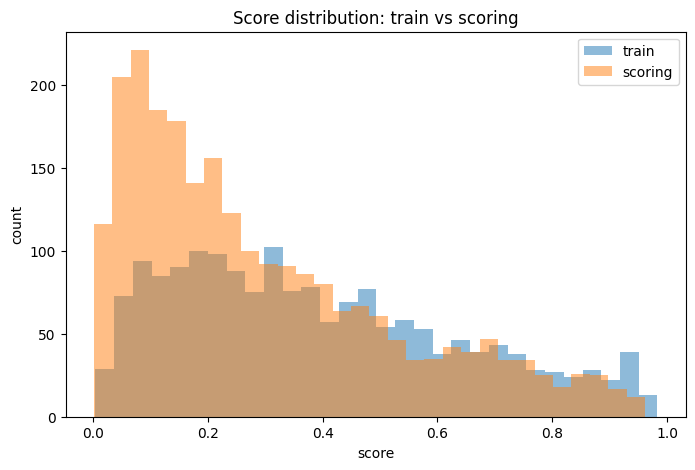

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(train_scores_df["score"], bins=30, alpha=0.5, label="train")
plt.hist(scoring_df["score"], bins=30, alpha=0.5, label="scoring")

plt.legend()
plt.title("Score distribution: train vs scoring")
plt.xlabel("score")
plt.ylabel("count")

plt.show()

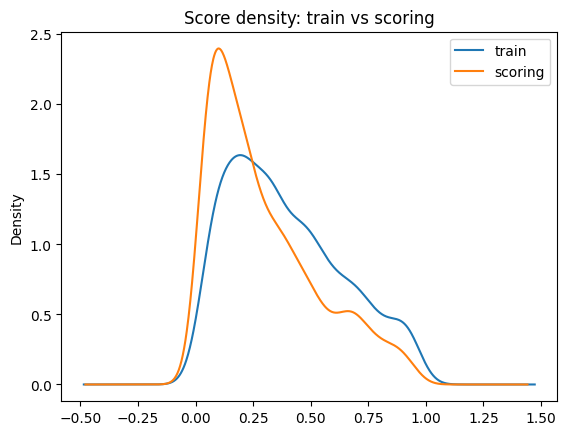

In [ ]:
train_scores_df["score"].plot(kind="kde", label="train")
scoring_df["score"].plot(kind="kde", label="scoring")

plt.legend()
plt.title("Score density: train vs scoring")
plt.show()

- смещение распределения **score в сторону меньших значений**
- При этом **форма распределения сохраняется**, что указывает на отсутствие критического изменения поведения модели.

### Расчёт PSI (Population Stability Index)

*насколько изменилось распределение признака между двумя выборками*

Определение бинов

In [ ]:
n_bins = 10

bins = np.linspace(train_scores_df["score"].min(),
                   train_scores_df["score"].max(),
                   n_bins + 1)

Расчёт распределения

In [ ]:
train_counts = np.histogram(train_scores_df["score"], bins=bins)[0]
scoring_counts = np.histogram(scoring_df["score"], bins=bins)[0]

# Приводим к долям
train_dist = train_counts / train_counts.sum()
scoring_dist = scoring_counts / scoring_counts.sum()

*защита от зануления?*

In [ ]:
eps = 1e-6

train_dist = np.where(train_dist == 0, eps, train_dist)
scoring_dist = np.where(scoring_dist == 0, eps, scoring_dist)

Расчёт PSI

In [ ]:
psi = np.sum((train_dist - scoring_dist) * np.log(train_dist / scoring_dist))

In [ ]:
psi

np.float64(0.1964455876856332)

In [ ]:
psi_df = pd.DataFrame({
    "bin_left": bins[:-1],
    "bin_right": bins[1:],
    "train_dist": train_dist,
    "scoring_dist": scoring_dist})

In [ ]:
psi_df

,bin_left,bin_right,train_dist,scoring_dist
0,0.004413,0.102280,0.112579,0.241351
1,0.102280,0.200146,0.157955,0.207586
2,0.200146,0.298013,0.149914,0.154648
3,0.298013,0.395880,0.147042,0.112964
4,0.395880,0.493746,0.116600,0.087120
5,0.493746,0.591613,0.094773,0.056690
6,0.591613,0.689480,0.070649,0.050855
7,0.689480,0.787347,0.062608,0.043351
8,0.787347,0.885213,0.045376,0.030013
9,0.885213,0.983080,0.042504,0.015423


#### Анализ стабильности score (PSI)

- Значение `PSI` составило `~0.20`, что указывает на `умеренный сдвиг` распределения score между обучающей и текущей выборками.

- Наблюдается **увеличение доли клиентов с низкими значениями score** и снижение доли клиентов с высокими значениями.  
*Это может свидетельствовать об изменении характеристик входящих данных или клиентской базы.*

В целом модель остаётся применимой, однако наблюдаемый сдвиг требует мониторинга и потенциальной переоценки модели при дальнейшем использовании.

#### Возможные улучшения расчёта PSI

- Использовать **квантильное разбиение** вместо равномерного  
  → позволит получить более устойчивую оценку PSI за счёт равномерного распределения наблюдений по бинам

- Формировать **бины строго по train-выборке**  
  → обеспечит корректное сравнение с базовым распределением и исключит leakage

- **Увеличить число бинов** (например, до 20)  
  → даст более детализированное представление о сдвиге распределения

- **Добавить визуализацию долей по бинам**  
  → позволит наглядно увидеть, в каких диапазонах score происходит основной сдвиг

- Проверить стабильность PSI при разных биннингах  
  → повысит надёжность выводов о наличии сдвига

- `(actual - expected) * np.log(actual / expected)`

### Итоговая рекомендация

**Новая стратегия**, основанная на отборе top-25% клиентов по score, **демонстрирует значительное улучшение экономического эффекта** по сравнению с текущей стратегией:

- снижение количества контактов;
- рост суммарного дохода;
- увеличение итогового экономического эффекта (~+1.7 млн рублей).

При этом анализ стабильности score показал **умеренный сдвиг** распределения (`PSI ≈ 0.20`), связанный с увеличением доли клиентов с низкими значениями score.

Таким образом, **модель рекомендуется к запуску**, так как она обеспечивает существенный бизнес-эффект.  
Однако рекомендуется:

- организовать мониторинг распределения score;
- контролировать качество модели на новых данных;
- рассмотреть переобучение модели при дальнейшем росте сдвига.

В текущем состоянии модель **можно использовать** в продакшене с контролем стабильности.

# БЫСТРЫЕ ОТВЕТЫ

## ML-1. Базовая модель вероятности оплаты

1. Полный код в отдельных пунктах

2. Метрики:

In [ ]:
metrics_table

,metric,value
0,ROC-AUC,0.789407
1,PR-AUC,0.719074
2,precision@top30%,0.703065


3. Выводы:

- Базовая логистическая регрессия показала хорошее качество ранжирования клиентов по вероятности оплаты.
- Значение `ROC-AUC ~0.79` говорит о том, что модель уверенно разделяет клиентов по целевому событию(оплате).
- `PR-AUC ~0.72` подтверждает устойчивое качество с учётом умеренного дисбаланса классов.
- `precision@top30% ~0.70` означает, что среди 30% клиентов с наибольшей предсказанной вероятностью оплаты реально платят около 70%, что делает модель пригодной как baseline для задач приоритизации.

## ML-2. Бустинг и сравнение с baseline

1. Полный код в отдельных блоках

2. Метрики

In [ ]:
xgb_compare

,metric,baseline,catboost,xgboost
0,ROC-AUC,0.789407,0.788510,0.773753
1,PR-AUC,0.719074,0.715904,0.696273
2,precision@top30%,0.703065,0.708812,0.685824


3. Выводы:

- **CatBoost** показал сопоставимое качество с baseline по `ROC-AUC` и `PR-AUC`.
- Наблюдается **небольшое** улучшение по `precision@top30%`, что указывает на более точное выделение клиентов с высокой вероятностью оплаты.
- По сегментам значительного устойчивого улучшения не выявлено: в ряде групп качество **сопоставимо с baseline**, в отдельных — наблюдается **снижение**.
- **Наибольшее влияние на предсказание** оказывают признаки, связанные с уровнем просрочки, контактами и историей взаимодействия с клиентом.

## ML-3. Порог отсечения, бизнес-эффект и мониторинг

1. Полный код в отдельных блоках

2. Расчёты:

In [ ]:
print('Таблица сравнения стратегий')
comparison_strategy

Таблица сравнения стратегий


,metric,current_strategy,new_strategy,difference
0,selected_customers,768.00,600.00,-168.00
1,revenue,4505520.09,6265682.52,1760162.43
2,contact_cost,26880.00,21000.00,-5880.00
3,economic_effect,4478640.09,6244682.52,1766042.43


- Новая стратегия увеличивает экономический эффект примерно на `~1.7` млн рублей при снижении числа контактов.
- Модель позволяет более точно отбирать клиентов с высокой вероятностью оплаты и повышает эффективность обзвона.

In [ ]:
print(f'PSI: {psi}')
psi_df

PSI: 0.1964455876856332


,bin_left,bin_right,train_dist,scoring_dist
0,0.004413,0.102280,0.112579,0.241351
1,0.102280,0.200146,0.157955,0.207586
2,0.200146,0.298013,0.149914,0.154648
3,0.298013,0.395880,0.147042,0.112964
4,0.395880,0.493746,0.116600,0.087120
5,0.493746,0.591613,0.094773,0.056690
6,0.591613,0.689480,0.070649,0.050855
7,0.689480,0.787347,0.062608,0.043351
8,0.787347,0.885213,0.045376,0.030013
9,0.885213,0.983080,0.042504,0.015423


- `PSI ≈ 0.20` указывает на умеренный сдвиг распределения score, что требует мониторинга, но не препятствует использованию модели.

3. Итоговая рекомендация

- Модель рекомендуется к запуску, так как обеспечивает значительный прирост экономического эффекта.
- При этом необходимо организовать мониторинг распределения score и качества модели на новых данных.